# 01 · System Dynamics & Linearisation
Derives the linearised state-space model for the **triple inverted pendulum on a cart**
and examines open-loop stability — mirroring `matlab/linearize.m` in Python.

**State vector (8 states):** `[x, ẋ, θ₁, θ̇₁, θ₂, θ̇₂, θ₃, θ̇₃]`
θ₁ absolute; θ₂ relative to link 1; θ₃ relative to link 2.
**Input:** F — horizontal cart force [N]

In [5]:
# Install packages into whichever Python kernel VS Code is using
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "matplotlib", "numpy", "scipy", "pandas",
    "gymnasium", "stable-baselines3", "filterpy"
], check=True)
print('packages ready')

packages ready


In [6]:
import sys, os
# Works whether jupyter is launched from python/ or python/notebooks/
_nb_dir = os.path.abspath("")
_py_dir = _nb_dir if os.path.basename(_nb_dir) != "notebooks" else os.path.dirname(_nb_dir)
if _py_dir not in sys.path:
    sys.path.insert(0, _py_dir)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Physical Parameters

In [7]:
from utils import parameters as p
import pandas as pd

rows = [
    ("Cart mass M",        f"{p.M} kg"),
    ("Cart friction b",    f"{p.b} N·s/m"),
    ("Link 1  m₁, l₁",    f"{p.m1} kg,  {p.l1} m"),
    ("Link 1  I₁, b₁",    f"{p.I1:.4f} kg·m²,  {p.b1} N·m·s/rad"),
    ("Link 2  m₂, l₂",    f"{p.m2} kg,  {p.l2} m"),
    ("Link 2  I₂, b₂",    f"{p.I2:.4f} kg·m²,  {p.b2} N·m·s/rad"),
    ("Link 3  m₃, l₃",    f"{p.m3} kg,  {p.l3} m"),
    ("Link 3  I₃, b₃",    f"{p.I3:.4f} kg·m²,  {p.b3} N·m·s/rad"),
    ("Gravity g",          f"{p.g} m/s²"),
]
pd.DataFrame(rows, columns=["Parameter", "Value"]).style.hide(axis="index")

Parameter,Value
Cart mass M,1.0 kg
Cart friction b,0.1 N·s/m
"Link 1 m₁, l₁","0.5 kg, 0.6 m"
"Link 1 I₁, b₁","0.0600 kg·m², 0.01 N·m·s/rad"
"Link 2 m₂, l₂","0.4 kg, 0.5 m"
"Link 2 I₂, b₂","0.0333 kg·m², 0.01 N·m·s/rad"
"Link 3 m₃, l₃","0.3 kg, 0.4 m"
"Link 3 I₃, b₃","0.0160 kg·m², 0.01 N·m·s/rad"
Gravity g,9.81 m/s²


## Linearised State-Space  (A, B)
The Lagrangian equations of motion are linearised around the fully upright equilibrium
(all angles = 0, all velocities = 0).  At this point sin θ ≈ θ, cos θ ≈ 1, giving
constant A and B matrices.

In [8]:
from utils.dynamics import get_linear_system

A, B, C, D = get_linear_system()
state_names = ["x", "xd", "th1", "th1d", "th2", "th2d", "th3", "th3d"]

print("A  (8×8):")
df_A = pd.DataFrame(A, index=state_names, columns=state_names)
display(df_A.style.format("{:.3f}").background_gradient(cmap="RdBu_r", axis=None))

print("\nB  (8×1)  — generalised input (cart force F):")
pd.DataFrame(B, index=state_names, columns=["F"]).style.format("{:.4f}")

A  (8×8):


,x,xd,th1,th1d,th2,th2d,th3,th3d
x,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
xd,0.000,-0.078,-6.942,0.012,-0.285,-0.011,-0.006,-0.001
th1,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
th1d,0.000,0.119,25.692,-0.071,-14.258,0.128,-0.322,-0.051
th2,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
th2d,0.000,-0.108,-23.239,0.128,48.487,-0.349,-5.545,0.315
th3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
th3d,0.000,-0.010,-2.217,-0.051,-30.937,0.315,33.600,-0.834



B  (8×1)  — generalised input (cart force F):


,F
x,0.0000
xd,0.7762
th1,0.0000
th1d,-1.1904
th2,0.0000
th2d,1.0768
th3,0.0000
th3d,0.1027


## Open-Loop Eigenvalues

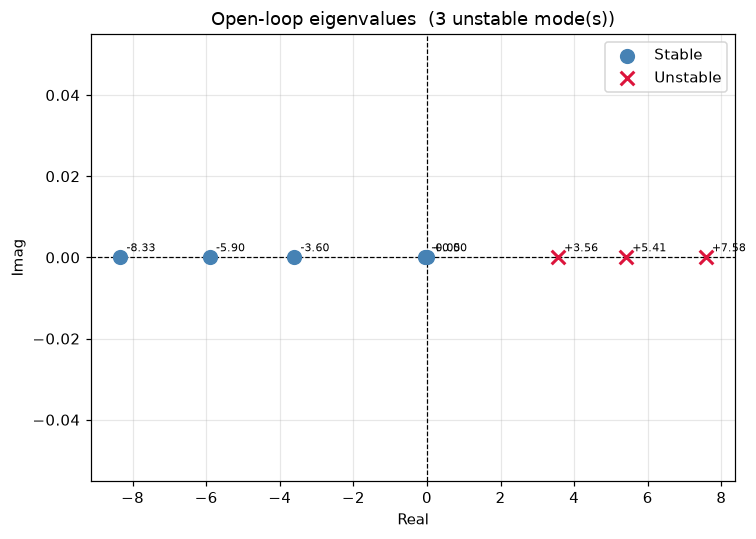


3 unstable mode(s) — open-loop system is UNSTABLE (as expected).


In [9]:
ev = np.linalg.eigvals(A)
n_unstable = int(np.sum(ev.real > 1e-9))

fig, ax = plt.subplots(figsize=(7, 5))
ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
ax.scatter(ev.real[ev.real <= 0], ev.imag[ev.real <= 0],
           color="steelblue", s=80, zorder=5, label="Stable")
ax.scatter(ev.real[ev.real > 0],  ev.imag[ev.real > 0],
           color="crimson",    s=80, zorder=5, marker="x", linewidths=2, label="Unstable")
for e in ev:
    ax.annotate(f"{e.real:+.2f}", (e.real, e.imag),
                textcoords="offset points", xytext=(4, 4), fontsize=7)
ax.set_xlabel("Real"); ax.set_ylabel("Imag")
ax.set_title(f"Open-loop eigenvalues  ({n_unstable} unstable mode(s))")
ax.legend(); plt.tight_layout(); plt.show()
print(f"\n{n_unstable} unstable mode(s) — open-loop system is UNSTABLE (as expected).")

## Cross-Check: Nonlinear Mass Matrix at Equilibrium
At the upright equilibrium the nonlinear mass matrix should equal the linearised one.

In [10]:
from utils.dynamics import _mass_matrix_nl

q_eq = np.zeros(4)
M_nl  = _mass_matrix_nl(q_eq)

# Linearised mass matrix (extracted from M_mat in dynamics.py)
a1 = p.m1*p.lc1 + p.m2*(p.l1+p.lc2) + p.m3*(p.l1+p.l2+p.lc3)
a2 = p.m2*p.lc2 + p.m3*(p.l2+p.lc3)
a3 = p.m3*p.lc3
M11 = p.M+p.m1+p.m2+p.m3
M_lin_11 = np.array([[M11, a1, a2, a3]])   # just first row for quick check

print("Nonlinear M[0,:] at equilibrium :", M_nl[0].round(6))
print("Linearised M[0,:]               :", np.array([M11, a1, a2, a3]).round(6))
print("Max abs difference              :", np.abs(M_nl[0] - [M11,a1,a2,a3]).max())

Nonlinear M[0,:] at equilibrium : [2.2  0.88 0.31 0.06]
Linearised M[0,:]               : [2.2  0.88 0.31 0.06]
Max abs difference              : 0.0
